## 准备数据集

In [151]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)



# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

"""
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
"""

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


'\nimport urllib.request\nimport zipfile\nimport os\nfrom pathlib import Path\n\nurl = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"\nzip_path = "sms_spam_collection.zip"\nextracted_path = "sms_spam_collection"\ndata_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"\n\ndef download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):\n    if data_file_path.exists():\n        print(f"{data_file_path} already exists. Skipping download and extraction.")\n        return\n\n    # Downloading the file\n    with urllib.request.urlopen(url) as response:\n        with open(zip_path, "wb") as out_file:\n            out_file.write(response.read())\n\n    # Unzipping the file\n    with zipfile.ZipFile(zip_path, "r") as zip_ref:\n        zip_ref.extractall(extracted_path)\n\n    # Add .tsv file extension\n    original_file_path = Path(extracted_path) / "SMSSpamCollection"\n    os.rename(original_file_path, data_file_path)\n    print(f"File downloade

In [152]:
import pandas as pd
df = pd.read_csv(
    "datasets/sms_spam_collection/SMSSpamCollection.tsv", sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [153]:
print(df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [154]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df

In [155]:
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [156]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [157]:
def random_split(df, train_frac, valid_frac):
    df = df.sample(
        frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    valid_end = train_end + int(len(df) * valid_frac)
    train_df = df[:train_end]
    valid_df = df[train_end:valid_end]
    test_df = df[valid_end:]
    return train_df, valid_df, test_df

train_df, valid_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [158]:
train_df.to_csv('datasets/sms_spam_collection/train.csv', index=None)
valid_df.to_csv('datasets/sms_spam_collection/valid.csv', index=None)
test_df.to_csv('datasets/sms_spam_collection/test.csv', index=None)

## 创建数据加载器

In [159]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [160]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['Text']
        ]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                text[:self.max_length] for text in self.encoded_texts
            ]

        self.encoded_texts = [
            text + [pad_token_id] * (self.max_length - len(text)) for text in self.encoded_texts
        ]

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]['Label']
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            max_length = max(len(encoded_text), max_length)
        return max_length

In [161]:
train_dataset = SpamDataset(
    csv_file='datasets/sms_spam_collection/train.csv',
    max_length=None,
    tokenizer=tokenizer,
)
valid_dataset = SpamDataset(
    csv_file='datasets/sms_spam_collection/valid.csv',
    max_length=train_dataset.max_length,
    tokenizer=tokenizer,
)
test_dataset = SpamDataset(
    csv_file='datasets/sms_spam_collection/test.csv',
    max_length=train_dataset.max_length,
    tokenizer=tokenizer,
)

In [162]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, num_workers=num_workers)


## 初始化预训练权重

In [163]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "dropout": 0.0,        # Dropout rate
    "bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [164]:
import torch
from models.GPTModel import GPTModel
from utils import *
import tensorflow as tf
import json
from gpt_download import load_gpt2_params_from_tf_ckpt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = "../models/GPT2-124M/124M"
tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)
model = GPTModel(BASE_CONFIG)
model.eval()
load_weights_into_gpt(model, params)

In [165]:
text_1 = "Every effort moves you"
token_ids = generate(
    model=model,
        idx=text_to_token_ids(text_1, tokenizer),
        max_new_tokens=15,
        context_size=BASE_CONFIG['context_length'],
        top_k=25,
        temperature=1.3
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you away from the idea of seeing the future in the present that could never happen


In [166]:
print(model)

GPTModel(
  (tok_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(1024, 768)
  (dropout): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (w_q): Linear(in_featur

In [167]:
for param in model.parameters():
    param.requires_grad = False
num_classes = 2
model.out_head = torch.nn.Linear(BASE_CONFIG['emb_dim'], num_classes)
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [168]:
def calc_acc_loader(data_loader, model, device, num_batches=None):
    model.eval()
    corr_preds, num_examples = 0, 0
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)
        with torch.no_grad():
            logits = model(input_batch)[:, -1, :]
        preds = logits.argmax(dim=-1)
        num_examples += preds.shape[0]
        corr_preds += (preds == target_batch).sum().item()
    return corr_preds / num_examples
        


In [169]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [170]:
model.to(device)
train_acc = calc_acc_loader(train_loader, model, device)
val_acc = calc_acc_loader(valid_loader, model, device)
test_acc = calc_acc_loader(test_loader, model, device)
print(f"train acc: {train_acc:.2f}, val acc: {val_acc:.2f}, test acc: {test_acc:.2f}")

train acc: 0.50, val acc: 0.47, test acc: 0.50


In [171]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    valid_loss = calc_loss_loader(valid_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Train loss: {train_loss:.3f} | Valid loss: {valid_loss:.3f} | Test loss: {test_loss:.3f}")



Train loss: 0.709 | Valid loss: 0.699 | Test loss: 0.748


In [172]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
        valid_loss = calc_loss_loader(val_loader, model, device, eval_iter)
    model.train()
    return train_loss, valid_loss

In [173]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, 
                       epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    for epoch in range(epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, valid_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(valid_loss)
                print(f"Epoch {epoch}, step {global_step}, train loss {train_loss:.4f}, valid loss {valid_loss:.4f}")
        train_acc = calc_acc_loader(train_loader, model, device, num_batches=eval_iter)
        valid_acc = calc_acc_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Epoch {epoch}, train acc {train_acc*100:.4f}% | valid acc {valid_acc*100:.4f}%")
        train_accs.append(train_acc)
        val_accs.append(valid_acc)
    return train_losses, val_losses, train_accs, val_accs, examples_seen



In [174]:
import time
t1 = time.time()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, valid_losses, train_accs, valid_accs, examples_seen = train_classifier_simple(model, train_loader, valid_loader, optimizer, device, num_epochs, eval_freq=50, eval_iter=5)
t2 = time.time()
print(f'Training time: {t2-t1} seconds')

Epoch 0, step 0, train loss 0.6262, valid loss 0.6220
Epoch 0, step 50, train loss 0.3986, valid loss 0.3611
Epoch 0, step 100, train loss 0.3058, valid loss 0.3061
Epoch 0, train acc 77.5000% | valid acc 87.5000%
Epoch 1, step 150, train loss 0.2639, valid loss 0.2715
Epoch 1, step 200, train loss 0.1595, valid loss 0.2649
Epoch 1, step 250, train loss 0.1994, valid loss 0.1692
Epoch 1, train acc 87.5000% | valid acc 85.0000%
Epoch 2, step 300, train loss 0.1998, valid loss 0.2730
Epoch 2, step 350, train loss 0.0394, valid loss 0.2541
Epoch 2, train acc 97.5000% | valid acc 92.5000%
Epoch 3, step 400, train loss 0.1098, valid loss 0.1756
Epoch 3, step 450, train loss 0.0090, valid loss 0.2052
Epoch 3, step 500, train loss 0.1259, valid loss 0.2091
Epoch 3, train acc 97.5000% | valid acc 92.5000%
Epoch 4, step 550, train loss 0.0168, valid loss 0.1652
Epoch 4, step 600, train loss 0.0135, valid loss 0.2120
Epoch 4, train acc 95.0000% | valid acc 92.5000%
Training time: 18.512160539627

In [175]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen, train_values, valid_values, label="Loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"training {label}")
    ax1.plot(epochs_seen, valid_values, linestyle="-.", label=f"valid {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples")

    fig.tight_layout()
    plt.show()

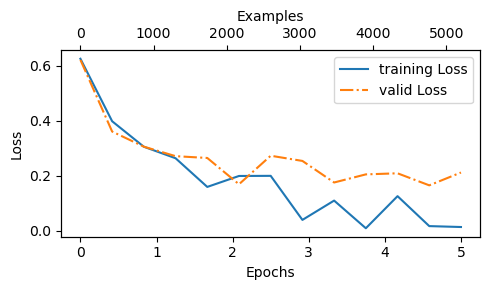

In [183]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, valid_losses)

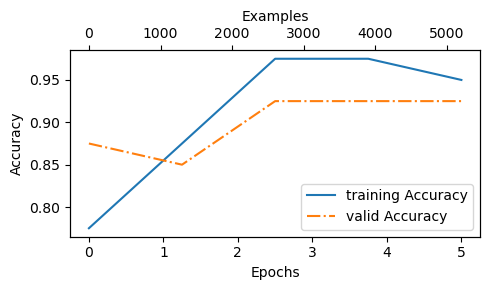

In [184]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, valid_accs, label="Accuracy")

## 使用大模型作为垃圾消息分类器

In [ ]:
def classify_review(
        text, model, tokenizer, device, max_length, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_embedding.weight.shape[0]

    input_ids = input_ids[:min(len(input_ids), supported_context_length)]
    input_ids += [pad_token_id] * (supported_context_length - len(input_ids))

    input_tensor = torch.tensor(input_ids).to(device).unsqueeze(0)
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    pred = torch.argmax(logits, dim=-1).item()
    return "spam" if pred == 1 else "not spam"

In [194]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))

torch.Size([1024])
spam


In [195]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

torch.Size([1024])
not spam


In [ ]:
torch.save()